# Radio Synchrotron Modelling Analysis

This is a separate notebook just so I don't have to keep rerunning the chains when they look fine

In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

from astropy.cosmology import Planck18 as cosmo

from corner import corner

from astropy import constants as c

import syncfit

from otter import Otter

private_data_path = "private_otter_data"
db = Otter(
    url="http://localhost:8529",
    username="root",
    password="",
    datadir=private_data_path,
    gen_summary=True
)

In [2]:
def get_bounds(chain, ndim=3):
    
    medians, upper, lower = [], [], []
    for i in range(ndim):
        mcmc = np.percentile(chain[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        vals = [mcmc[1],(q[0]+q[1])/2]

        medians.append(mcmc[1])
        upper.append(q[1])
        lower.append(q[0])

    return medians, upper, lower


In [3]:
labels = ["p", 'log_F_nu', 'log_nu_a']

best_fit_params = dict(
    name = [],
    mjd = [],
    p = [],
    p_up = [],
    p_lo = [],
    p_chain = [],
    log_F_nu = [],
    log_F_nu_up = [],
    log_F_nu_lo = [],
    log_F_nu_chain = [],
    log_nu_a = [],
    log_nu_a_up = [],
    log_nu_a_lo = [],
    log_nu_a_chain = []
)

for jfile in glob.glob(os.path.join(os.getcwd(), "*chains.json")):

    with open(jfile, "r") as j:
        chain_dict = json.load(j)
    
    tname = jfile.split('-')[1].split('/')[1]

    print(tname)

    for k, chain in chain_dict.items():
        medians, uplims, lowlims = get_bounds(np.array(chain))
        print(f"\tMJD = {k}")
        for median, uplim, lowlim, lab, chain_by_key in zip(medians, uplims, lowlims, labels, np.array(chain).T):
            print(f"\t\t${lab} = {median:.2f}^+{uplim:.2f}_-{lowlim:.2f}$")

            best_fit_params[lab].append(median)
            best_fit_params[f"{lab}_up"].append(uplim)
            best_fit_params[f"{lab}_lo"].append(lowlim)
            best_fit_params[f"{lab}_chain"].append(chain_by_key)
        best_fit_params["mjd"].append(k)
        best_fit_params["name"].append(tname)
        
        
    
    print()

res = pd.DataFrame(best_fit_params)

SDSSJ1241
	MJD = 57629.5
		$p = 3.57^+0.21_-0.35$
		$log_F_nu = 1.35^+0.45_-0.37$
		$log_nu_a = 8.74^+0.37_-0.38$
	MJD = 57959.0
		$p = 3.88^+0.09_-0.52$
		$log_F_nu = 1.18^+0.03_-0.04$
		$log_nu_a = 8.98^+0.02_-0.14$
	MJD = 58754.0
		$p = 3.96^+0.03_-0.64$
		$log_F_nu = 0.91^+0.02_-0.03$
		$log_nu_a = 9.01^+0.01_-0.19$
	MJD = 59050.0
		$p = 2.29^+0.23_-0.13$
		$log_F_nu = 1.24^+0.51_-0.56$
		$log_nu_a = 7.58^+0.90_-0.84$
	MJD = 59500.0
		$p = 3.65^+0.26_-0.58$
		$log_F_nu = 1.40^+0.43_-0.60$
		$log_nu_a = 8.44^+0.42_-0.34$

SDSSJ0938
	MJD = 57459.0
		$p = 3.19^+0.37_-0.40$
		$log_F_nu = 1.12^+0.61_-0.46$
		$log_nu_a = 8.65^+0.56_-0.61$
	MJD = 57912.0
		$p = 3.09^+0.16_-0.14$
		$log_F_nu = 1.20^+0.53_-0.24$
		$log_nu_a = 8.44^+0.33_-0.57$

SDSSJ0748
	MJD = 57458.0
		$p = 2.81^+0.63_-0.48$
		$log_F_nu = 0.50^+0.97_-0.84$
		$log_nu_a = 8.15^+1.04_-1.16$
	MJD = 57914.0
		$p = 2.60^+0.45_-0.29$
		$log_F_nu = 0.38^+0.92_-0.73$
		$log_nu_a = 7.73^+1.04_-1.12$



In [4]:
# add in other information we need about each object

redshift = dict(
    SDSSJ1241 = db.get_meta(names="SDSS_J1241", query_private=True)[0].get_redshift(),
    SDSSJ0938 = db.get_meta(names="SDSS_J0938", query_private=True)[0].get_redshift(),
    SDSSJ0748 = db.get_meta(names="SDSS_J0748", query_private=True)[0].get_redshift()
)

disc_date = dict(
    SDSSJ1241 = db.get_meta(names="SDSS_J1241", query_private=True)[0].get_discovery_date().mjd,
    SDSSJ0938 = db.get_meta(names="SDSS_J0938", query_private=True)[0].get_discovery_date().mjd,
    SDSSJ0748 = db.get_meta(names="SDSS_J0748", query_private=True)[0].get_discovery_date().mjd
)

lum_dist = dict(
    SDSSJ1241 = None,
    SDSSJ0938 = None,
    SDSSJ0748 = None
)

for name, z in redshift.items():
    lum_dist[name] = cosmo.luminosity_distance(z).to("cm").value

res['z'] = res.name.map(redshift).astype(float)
res["lum_dist"] = res.name.map(lum_dist).astype(float)
res["disc_date"] = res.name.map(disc_date).astype(float)

res["dt"] = res.mjd.astype(float) - res.disc_date

# determine if each F_nu, p, and log_nu should be upperlimits
def is_upperlimit(df, key, model=syncfit.models.B5(), uplim_factor=3):
    
    key_prior = model.prior[key]
    
    median = df[key]
    up = df[f"{key}_up"]
    lo = df[f"{key}_lo"]
        
    return median+(up*uplim_factor) > key_prior[1]
    
    
res["log_F_nu_uplim"] = is_upperlimit(res, "log_F_nu")
res["log_nu_a_uplim"] = is_upperlimit(res, "log_nu_a")
res["p_uplim"] = is_upperlimit(res, "p")

res

/home/nfranz/astro-otter/otter/src/otter/io/transient.py:880: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:880: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(


,name,mjd,p,p_up,p_lo,p_chain,log_F_nu,log_F_nu_up,log_F_nu_lo,log_F_nu_chain,...,log_nu_a_up,log_nu_a_lo,log_nu_a_chain,z,lum_dist,disc_date,dt,log_F_nu_uplim,log_nu_a_uplim,p_uplim
0,SDSSJ1241,57629.5,3.571883,0.207684,0.352500,"[2.6544449137536517, 2.891115522708965, 3.4855...",1.348285,0.445148,0.365717,"[2.1097979984835487, 3.3348030172949894, 3.444...",...,0.368730,0.384122,"[8.673367736340861, 7.691903029780226, 9.61743...",0.0419,5.909865e+26,53062.0,4567.5,True,False,True
1,SDSSJ1241,57959.0,3.884762,0.087517,0.516807,"[2.24827282444955, 3.369757010813755, 3.893878...",1.176276,0.027493,0.037829,"[3.4814847236306763, 3.1059953508628997, 3.629...",...,0.020644,0.144287,"[6.447306545255683, 6.676500813565929, 10.4101...",0.0419,5.909865e+26,53062.0,4897.0,False,False,True
2,SDSSJ1241,58754.0,3.962760,0.032184,0.638261,"[3.658054650343267, 2.874216284091503, 2.73848...",0.906718,0.023966,0.033516,"[3.3933599475184337, 2.548504849755105, 2.5451...",...,0.013530,0.188532,"[7.628227304864245, 7.642793825624825, 7.92730...",0.0419,5.909865e+26,53062.0,5692.0,False,False,True
3,SDSSJ1241,59050.0,2.286125,0.227027,0.131538,"[3.4466969584507785, 2.1830945749402915, 3.929...",1.236303,0.508405,0.563423,"[3.4921218105828586, 3.0255743358250227, 3.120...",...,0.902605,0.836733,"[10.16731676300474, 8.834581715983838, 8.69165...",0.0419,5.909865e+26,53062.0,5988.0,True,False,False
4,SDSSJ1241,59500.0,3.646321,0.263945,0.577098,"[3.7796197296640375, 3.4174497857962587, 2.281...",1.400793,0.433374,0.601798,"[3.3025363522534947, 3.0385049930285906, 3.694...",...,0.420560,0.343002,"[6.411133391303311, 7.0022063502365315, 6.1372...",0.0419,5.909865e+26,53062.0,6438.0,True,False,True
5,SDSSJ0938,57459.0,3.194251,0.371804,0.404643,"[2.2011569579894967, 3.8511228693479964, 3.811...",1.121971,0.605158,0.455933,"[3.1714107219231558, 2.208297270240166, 3.9409...",...,0.557054,0.610101,"[7.026456695304441, 9.250304586647754, 9.95769...",0.1010,1.483898e+27,54092.0,3367.0,True,False,True
6,SDSSJ0938,57912.0,3.086663,0.157781,0.135965,"[2.1300867491059963, 2.807662076700631, 3.1250...",1.198764,0.534909,0.238301,"[2.269682394993618, 2.681436747037643, 3.19040...",...,0.328855,0.571719,"[8.172730799628624, 7.167466168998926, 7.03107...",0.1010,1.483898e+27,54092.0,3820.0,True,False,False
7,SDSSJ0748,57458.0,2.805552,0.631945,0.479167,"[3.899033196275586, 2.026466652634804, 2.56184...",0.496527,0.965694,0.839391,"[3.5212709167061593, 2.582284342821241, 3.1226...",...,1.037700,1.156877,"[9.499269868318777, 10.234326593191643, 9.2985...",0.0615,8.795978e+26,52935.0,4523.0,True,True,True
8,SDSSJ0748,57914.0,2.600990,0.445123,0.286097,"[3.4613106158395346, 2.1236805894870803, 3.519...",0.378762,0.921655,0.731863,"[2.3682626231634227, 3.0633433598470177, 3.358...",...,1.040126,1.119539,"[10.899147057686001, 8.736360656777755, 8.9296...",0.0615,8.795978e+26,52935.0,4979.0,True,False,False


In [5]:
def _mini_converter(d_L, nu_p):
    '''
    Converts to the appropriate units for the paper
    '''
    return d_L/1e28, nu_p/1e10

def Req(p, F_p_mJy, nu_p, z, d_L, epsilon_e=1, gamma=2, f_V=1, f_A=1):
    """
    Barniol Duran Eq. 27
    """
        
    d_L, nu_p = _mini_converter(d_L, nu_p)
    chi_e = (p-2)/(p-1) * epsilon_e * c.m_p.cgs.value/c.m_e.cgs.value
    gamma_m = np.max(np.array([
        np.ones(len(chi_e))*2,
        chi_e*(gamma-1)
    ]), axis=0)
    gamma_factor = gamma_m**((2-p)/(13+2*p))
    
    prefactor = 1e17 * (21.8 * 525**(p-1))**(1/(13+2*p))
    midfactor = F_p_mJy**((6+p)/(13+2*p)) * d_L**((2*(p+6))/(13+2*p)) * nu_p**(-1) * (1+z)**-((19+3*p)/(13+2*p)) 
    postfactor= f_A**-((5+p)/(13+2*p)) * f_V**-(1/(13+2*p)) * gamma**((p+8)/(13+2*p))
    
    return prefactor * midfactor * postfactor * gamma_factor

def Eeq(p, F_p_mJy, nu_p, z, d_L, epsilon_e=1, gamma=2, f_V=1, f_A=1):
    """
    Barniol Duran Eq. 28 
    """

    d_L, nu_p = _mini_converter(d_L, nu_p)
    chi_e = (p-2)/(p-1) * epsilon_e * c.m_p.cgs.value/c.m_e.cgs.value
    gamma_m = np.max(np.array([
        np.ones(len(chi_e))*2,
        chi_e*(gamma-1)
    ]), axis=0)
    gamma_factor = gamma_m**(-11*(p-2)/(13+2*p))
    
    prefactor = 1.3e48 * 21.8**-(2*(p+1)/(13+2*p)) * (525**(p-1))**(11/(13+2*p))
    midfactor = F_p_mJy**((14+3*p)/(13+2*p)) * d_L**(2*(3*p+14)/(13+2*p)) * nu_p**(-1) * (1+z)**-((27+5*p)/(13+2*p))
    postfactor= f_A**(-3*(p+1)/(13+2*p)) * f_V**(2*(p+1)/(13+2*p)) * gamma**-((5*p+16)/(13+2*p))

    return prefactor * midfactor * postfactor

### Bootstrap this calculation to propagate uncertainties

In [6]:
from functools import partial
from copy import deepcopy
from tqdm.notebook import tqdm, trange

# first bootstrap the calculations of Eeq and Req
n_sample = int(1e3)
n_bootstrap = int(1e4)

stat_method = np.median # or np.mean
stat_method_err = partial(np.percentile, q=[25,75]) # or np.std

gammas = range(1,10) #np.logspace(-1, 1, 10)

filename = f"bootstrap-result-{len(list(gammas))}nGamma-{n_bootstrap}nBootstrap.csv"

if os.path.exists(filename):
    result_df = pd.read_csv(filename)
    assert False, f"{filename} already exists! We read it in and don't need to run this all again!"

result_dfs = []
for gamma in gammas:
    res = deepcopy(res)
    
    Req_res, Eeq_res = [], []
    Req_err, Eeq_err = [], []
    for jfile in glob.glob(os.path.join(os.getcwd(), "*chains.json")):
    
        with open(jfile, "r") as j:
            chain_dict = json.load(j)
        
        tname = jfile.split('-')[1].split('/')[1]
    
        print(f"Starting {tname} w/ Gamma={gamma}...")
    
        z = float(redshift[tname])
        lum_dist_val = float(lum_dist[tname])
    
        for k, chain in chain_dict.items():
            means = np.array(
                [
                    [
                        stat_method(np.random.choice(v, n_sample)) 
                        for v in np.array(chain).T
                    ] 
                    for _ in range(n_bootstrap)
                ]
            )
    
            # now calculate the Req and Eeq from means
            means = np.array(means)
            Req_vals = Req(means[:,0], 10**means[:,1], 10**means[:,2], z, lum_dist_val, gamma=gamma)
            Eeq_vals = Eeq(means[:,0], 10**means[:,1], 10**means[:,2], z, lum_dist_val, gamma=gamma)
    
            Req_res_mid = stat_method(Req_vals)
            Req_res.append(Req_res_mid)
    
            Eeq_res_mid = stat_method(Eeq_vals)
            Eeq_res.append(Eeq_res_mid)
    
            
            Req_err_val = stat_method_err(Req_vals)
            if not isinstance(Req_err_val, (list, np.ndarray)):
                Req_err_val = [Req_err_val, Req_err_val]
            else:
                Req_err_val = [
                    Req_res_mid-Req_err_val[0],
                    Req_err_val[1]-Req_res_mid
                ]
                
            Eeq_err_val = stat_method_err(Eeq_vals)
            if not isinstance(Eeq_err_val, (list, np.ndarray)):
                Eeq_err_val = [Eeq_err_val, Eeq_err_val]
            else:
                Eeq_err_val = [
                    Eeq_res_mid-Eeq_err_val[0],
                    Eeq_err_val[1]-Eeq_res_mid
                ]
            
            Req_err.append(Req_err_val)
            Eeq_err.append(Eeq_err_val)
    
        print(f"Finished {tname} w/ Gamma={gamma}!")

    res["Req"] = Req_res
    res["Eeq"] = Eeq_res
    res["Req_up"] = np.array(Req_err)[:,1]
    res["Eeq_up"] = np.array(Eeq_err)[:,0]
    res["Req_lo"] = np.array(Req_err)[:,1]
    res["Eeq_lo"] = np.array(Eeq_err)[:,0]
    res["Gamma"] = gamma

    result_dfs.append(res)

result_df = pd.concat(result_dfs)

# if any of the extracted parameters are upperlimits than so should Eeq
result_df["Eeq_uplim"] = result_df.apply(
    lambda row : row.log_F_nu_uplim or row.log_nu_a_uplim or row.p_uplim,
    axis=1
)

result_df["Req_uplim"] = result_df.Eeq_uplim


# this takes a while to run so let's save the results
result_df.to_csv()

result_df

Starting SDSSJ1241 w/ Gamma=1...
Finished SDSSJ1241 w/ Gamma=1!
Starting SDSSJ0938 w/ Gamma=1...
Finished SDSSJ0938 w/ Gamma=1!
Starting SDSSJ0748 w/ Gamma=1...
Finished SDSSJ0748 w/ Gamma=1!
Starting SDSSJ1241 w/ Gamma=2...
Finished SDSSJ1241 w/ Gamma=2!
Starting SDSSJ0938 w/ Gamma=2...
Finished SDSSJ0938 w/ Gamma=2!
Starting SDSSJ0748 w/ Gamma=2...
Finished SDSSJ0748 w/ Gamma=2!
Starting SDSSJ1241 w/ Gamma=3...
Finished SDSSJ1241 w/ Gamma=3!
Starting SDSSJ0938 w/ Gamma=3...
Finished SDSSJ0938 w/ Gamma=3!
Starting SDSSJ0748 w/ Gamma=3...
Finished SDSSJ0748 w/ Gamma=3!
Starting SDSSJ1241 w/ Gamma=4...
Finished SDSSJ1241 w/ Gamma=4!
Starting SDSSJ0938 w/ Gamma=4...
Finished SDSSJ0938 w/ Gamma=4!
Starting SDSSJ0748 w/ Gamma=4...
Finished SDSSJ0748 w/ Gamma=4!
Starting SDSSJ1241 w/ Gamma=5...
Finished SDSSJ1241 w/ Gamma=5!
Starting SDSSJ0938 w/ Gamma=5...
Finished SDSSJ0938 w/ Gamma=5!
Starting SDSSJ0748 w/ Gamma=5...
Finished SDSSJ0748 w/ Gamma=5!
Starting SDSSJ1241 w/ Gamma=6...
Finishe

,name,mjd,p,p_up,p_lo,p_chain,log_F_nu,log_F_nu_up,log_F_nu_lo,log_F_nu_chain,...,p_uplim,Req,Eeq,Req_up,Eeq_up,Req_lo,Eeq_lo,Gamma,Eeq_uplim,Req_uplim
0,SDSSJ1241,57629.5,3.571883,0.207684,0.352500,"[2.6544449137536517, 2.891115522708965, 3.4855...",1.348285,0.445148,0.365717,"[2.1097979984835487, 3.3348030172949894, 3.444...",...,True,1.239004e+18,1.519651e+51,3.865110e+16,6.572859e+49,3.865110e+16,6.572859e+49,1,True,True
1,SDSSJ1241,57959.0,3.884762,0.087517,0.516807,"[2.24827282444955, 3.369757010813755, 3.893878...",1.176276,0.027493,0.037829,"[3.4814847236306763, 3.1059953508628997, 3.629...",...,True,6.271069e+17,1.088890e+51,1.270015e+15,9.370412e+48,1.270015e+15,9.370412e+48,1,True,True
2,SDSSJ1241,58754.0,3.962760,0.032184,0.638261,"[3.658054650343267, 2.874216284091503, 2.73848...",0.906718,0.023966,0.033516,"[3.3933599475184337, 2.548504849755105, 2.5451...",...,True,4.387515e+17,5.541208e+50,5.404018e+14,2.349849e+48,5.404018e+14,2.349849e+48,1,True,True
3,SDSSJ1241,59050.0,2.286125,0.227027,0.131538,"[3.4466969584507785, 2.1830945749402915, 3.929...",1.236303,0.508405,0.563423,"[3.4921218105828586, 3.0255743358250227, 3.120...",...,False,1.232935e+19,5.456313e+50,7.700000e+17,3.978838e+49,7.700000e+17,3.978838e+49,1,True,True
4,SDSSJ1241,59500.0,3.646321,0.263945,0.577098,"[3.7796197296640375, 3.4174497857962587, 2.281...",1.400793,0.433374,0.601798,"[3.3025363522534947, 3.0385049930285906, 3.694...",...,True,2.693281e+18,4.247155e+51,8.081973e+16,2.384535e+50,8.081973e+16,2.384535e+50,1,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,SDSSJ1241,59500.0,3.646321,0.263945,0.577098,"[3.7796197296640375, 3.4174497857962587, 2.281...",1.400793,0.433374,0.601798,"[3.3025363522534947, 3.0385049930285906, 3.694...",...,True,4.793467e+18,1.041327e+50,1.470346e+17,5.491968e+48,1.470346e+17,5.491968e+48,9,True,True
5,SDSSJ0938,57459.0,3.194251,0.371804,0.404643,"[2.2011569579894967, 3.8511228693479964, 3.811...",1.121971,0.605158,0.455933,"[3.1714107219231558, 2.208297270240166, 3.9409...",...,True,5.256782e+18,8.987448e+49,2.656482e+17,6.330030e+48,2.656482e+17,6.330030e+48,9,True,True
6,SDSSJ0938,57912.0,3.086663,0.157781,0.135965,"[2.1300867491059963, 2.807662076700631, 3.1250...",1.198764,0.534909,0.238301,"[2.269682394993618, 2.681436747037643, 3.19040...",...,False,9.594761e+18,1.412915e+50,3.944474e+17,6.777150e+48,3.944474e+17,6.777150e+48,9,True,True
7,SDSSJ0748,57458.0,2.805552,0.631945,0.479167,"[3.899033196275586, 2.026466652634804, 2.56184...",0.496527,0.965694,0.839391,"[3.5212709167061593, 2.582284342821241, 3.1226...",...,True,5.923922e+18,5.958555e+48,4.666238e+17,6.314780e+47,4.666238e+17,6.314780e+47,9,True,True


In [7]:
result_df

,name,mjd,p,p_up,p_lo,p_chain,log_F_nu,log_F_nu_up,log_F_nu_lo,log_F_nu_chain,...,p_uplim,Req,Eeq,Req_up,Eeq_up,Req_lo,Eeq_lo,Gamma,Eeq_uplim,Req_uplim
0,SDSSJ1241,57629.5,3.571883,0.207684,0.352500,"[2.6544449137536517, 2.891115522708965, 3.4855...",1.348285,0.445148,0.365717,"[2.1097979984835487, 3.3348030172949894, 3.444...",...,True,1.239004e+18,1.519651e+51,3.865110e+16,6.572859e+49,3.865110e+16,6.572859e+49,1,True,True
1,SDSSJ1241,57959.0,3.884762,0.087517,0.516807,"[2.24827282444955, 3.369757010813755, 3.893878...",1.176276,0.027493,0.037829,"[3.4814847236306763, 3.1059953508628997, 3.629...",...,True,6.271069e+17,1.088890e+51,1.270015e+15,9.370412e+48,1.270015e+15,9.370412e+48,1,True,True
2,SDSSJ1241,58754.0,3.962760,0.032184,0.638261,"[3.658054650343267, 2.874216284091503, 2.73848...",0.906718,0.023966,0.033516,"[3.3933599475184337, 2.548504849755105, 2.5451...",...,True,4.387515e+17,5.541208e+50,5.404018e+14,2.349849e+48,5.404018e+14,2.349849e+48,1,True,True
3,SDSSJ1241,59050.0,2.286125,0.227027,0.131538,"[3.4466969584507785, 2.1830945749402915, 3.929...",1.236303,0.508405,0.563423,"[3.4921218105828586, 3.0255743358250227, 3.120...",...,False,1.232935e+19,5.456313e+50,7.700000e+17,3.978838e+49,7.700000e+17,3.978838e+49,1,True,True
4,SDSSJ1241,59500.0,3.646321,0.263945,0.577098,"[3.7796197296640375, 3.4174497857962587, 2.281...",1.400793,0.433374,0.601798,"[3.3025363522534947, 3.0385049930285906, 3.694...",...,True,2.693281e+18,4.247155e+51,8.081973e+16,2.384535e+50,8.081973e+16,2.384535e+50,1,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,SDSSJ1241,59500.0,3.646321,0.263945,0.577098,"[3.7796197296640375, 3.4174497857962587, 2.281...",1.400793,0.433374,0.601798,"[3.3025363522534947, 3.0385049930285906, 3.694...",...,True,4.793467e+18,1.041327e+50,1.470346e+17,5.491968e+48,1.470346e+17,5.491968e+48,9,True,True
5,SDSSJ0938,57459.0,3.194251,0.371804,0.404643,"[2.2011569579894967, 3.8511228693479964, 3.811...",1.121971,0.605158,0.455933,"[3.1714107219231558, 2.208297270240166, 3.9409...",...,True,5.256782e+18,8.987448e+49,2.656482e+17,6.330030e+48,2.656482e+17,6.330030e+48,9,True,True
6,SDSSJ0938,57912.0,3.086663,0.157781,0.135965,"[2.1300867491059963, 2.807662076700631, 3.1250...",1.198764,0.534909,0.238301,"[2.269682394993618, 2.681436747037643, 3.19040...",...,False,9.594761e+18,1.412915e+50,3.944474e+17,6.777150e+48,3.944474e+17,6.777150e+48,9,True,True
7,SDSSJ0748,57458.0,2.805552,0.631945,0.479167,"[3.899033196275586, 2.026466652634804, 2.56184...",0.496527,0.965694,0.839391,"[3.5212709167061593, 2.582284342821241, 3.1226...",...,True,5.923922e+18,5.958555e+48,4.666238e+17,6.314780e+47,4.666238e+17,6.314780e+47,9,True,True


/home/nfranz/.local/lib/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/home/nfranz/.local/lib/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/home/nfranz/.local/lib/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/home/nfranz/.local/lib/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[

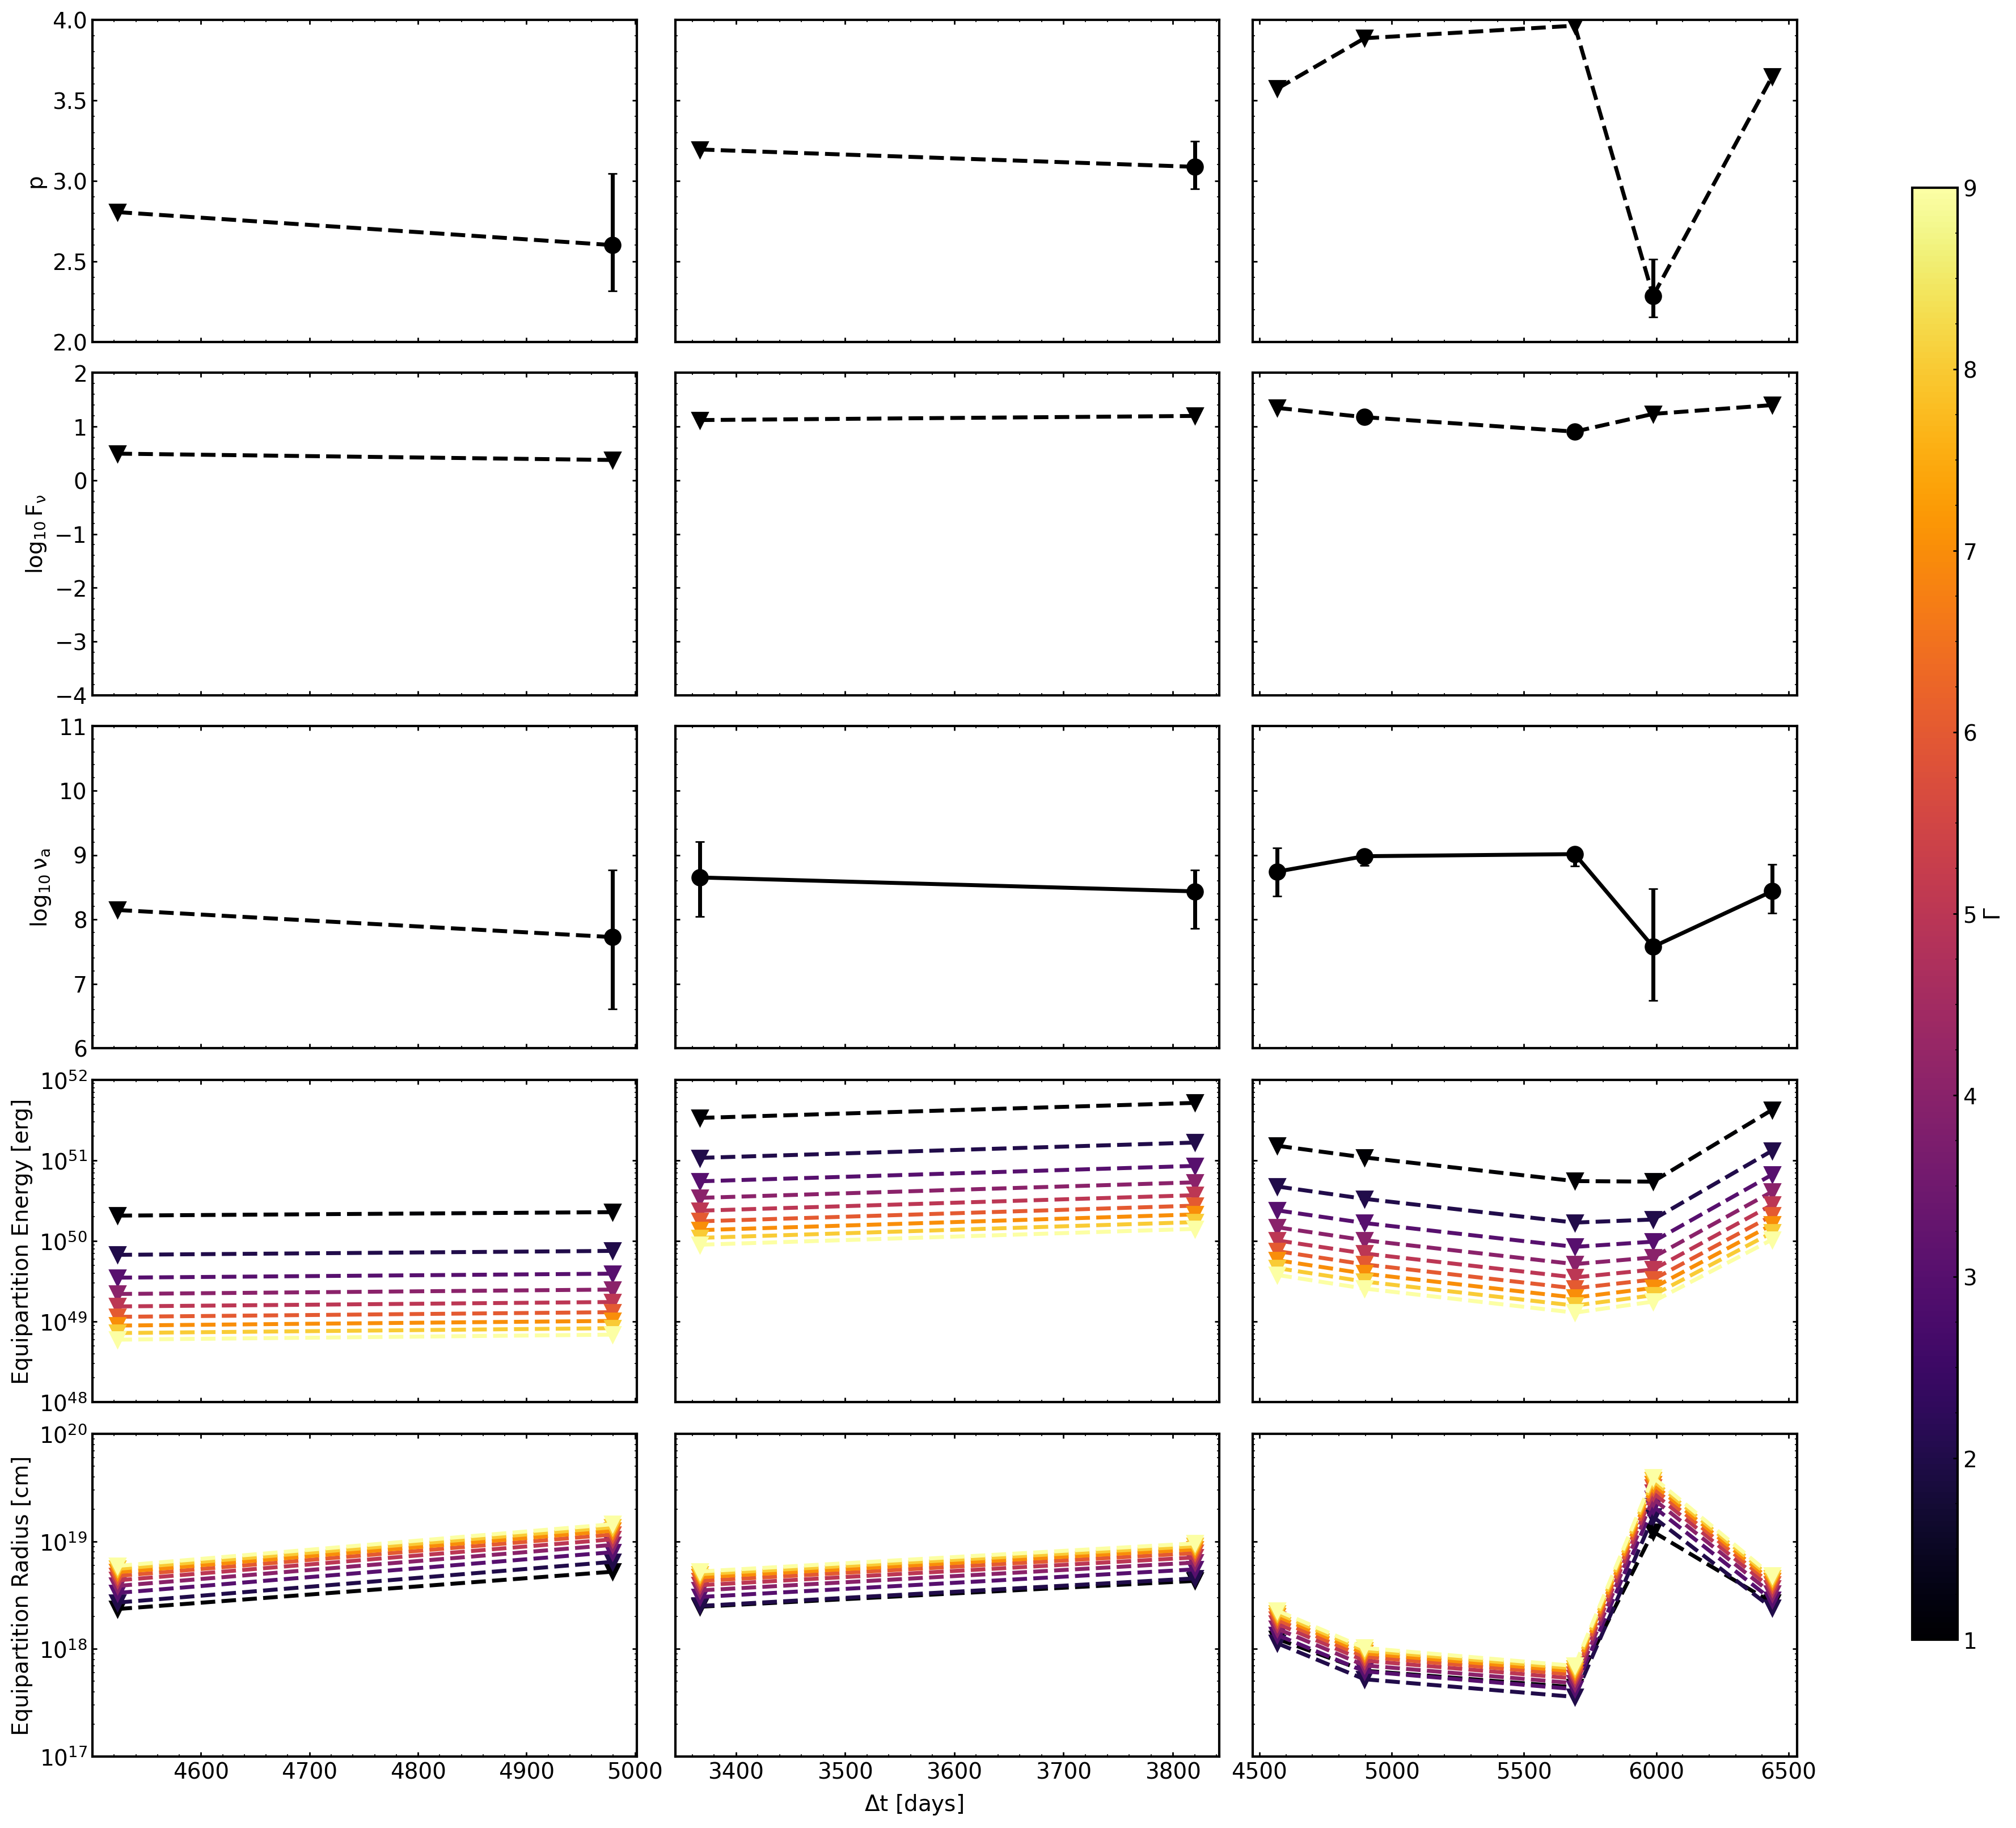

In [9]:
fig, axs = plt.subplots(5,3, sharex="col", sharey="row", figsize=(16,16), layout="constrained")


keys = {
    "p" : "p",
    "log_F_nu": r"$\log_{10} F_{\nu}$",
    "log_nu_a": r"$\log_{10} \nu_a$",
    "Eeq" : "Equipartition Energy [erg]",
    "Req" : "Equipartition Radius [cm]",
    # "Gamma" : r"$\Gamma$"
}

ranges = {
    "Eeq" : (1e48, 1e52),
    "Req" : (1e17, 1e20),
    # "p": (2,4),
    # "log_F_nu": (0,5),
    # "log_nu_a": (6,10)
    # "Gamma" : (1e1, 1e3)
}

colorbar_keys = {"Eeq", "Req"}

gammas = result_df.Gamma.unique()
n_lines = len(list(gammas))
cmap = mpl.colormaps['inferno']
colors = cmap(np.linspace(0,1,n_lines))

xvar = "dt"

priors = syncfit.models.B5().prior
ranges = priors | ranges # this will default to the priors but replace them with anything in ranges

label_fs = 14
ms = 10

for jj, (c, (gamma, df)) in enumerate(zip(colors, result_df.groupby("Gamma"))):
    for ii, (ax1d, (key, label)) in enumerate(zip(axs, keys.items())):
        ax1d[0].set_ylabel(label, fontsize=label_fs)
        for ax, (name, grp) in zip(ax1d, df.groupby("name")):
            if key in colorbar_keys:
                cplot = c
            elif jj > 0:
                continue # we can skip these keys the 2nd-nth time
            else:
                cplot = 'k'
            
            not_uplim = grp[~grp[key+"_uplim"]]
            ax.errorbar(
                not_uplim[xvar], 
                not_uplim[key], 
                yerr=(not_uplim[key+"_lo"], not_uplim[key+"_up"]), 
                marker='o', 
                linestyle='none', 
                color=cplot,
                capsize=3,
                markersize=ms
            )

            uplims = grp[grp[key+"_uplim"]]
            ax.plot(
                uplims[xvar],
                uplims[key],
                marker='v',
                linestyle='none',
                color=cplot,
                markersize=ms
            )
            
            grp = grp.reset_index()
            for ii,row in grp.iterrows():
                
                if ii == 0:
                    # just check if the next one is an upperlimit
                    hasuplim = row[key+"_uplim"] or grp.iloc[ii+1][key+"_uplim"]
                elif ii == len(grp)-1:
                    hasuplim = row[key+"_uplim"] or grp.iloc[ii-1][key+"_uplim"]
                else:
                    hasuplim = row[key+"_uplim"] or grp.iloc[ii-1][key+"_uplim"] or grp.iloc[ii+1][key+"_uplim"]
                
                linestyle='-'
                if hasuplim:
                    linestyle='--'
                
                ax.plot(
                    grp.iloc[ii-1:ii+1][xvar],
                    grp.iloc[ii-1:ii+1][key],
                    marker='none',
                    linestyle=linestyle,
                    color=cplot
                )
                
            if not ii:
                ax.set_title(f"{name}", fontsize=label_fs)
    
            ax.set_ylim(*ranges[key])
            # ax.set_xscale("log")

axs[-1][0].set_yscale("log")
axs[-2][0].set_yscale("log")

cax = plt.axes((1.05, 0.1, 0.025, 0.8))
cbar = fig.colorbar(
    mpl.cm.ScalarMappable(cmap=cmap, norm=None), 
    cax=cax,
    ticks=np.linspace(0, 1, len(gammas)),
)
cbar.ax.set_ylabel(r"$\Gamma$", fontsize=label_fs)
cbar.ax.set_yticklabels(list(gammas), fontsize=label_fs)

fig.supxlabel(r"$\Delta$t [days]", fontsize=label_fs)

fig.savefig("equipartition-results-bootstrap.png", bbox_inches="tight")

/home/nfranz/.local/lib/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/home/nfranz/.local/lib/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/home/nfranz/.local/lib/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/home/nfranz/.local/lib/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[

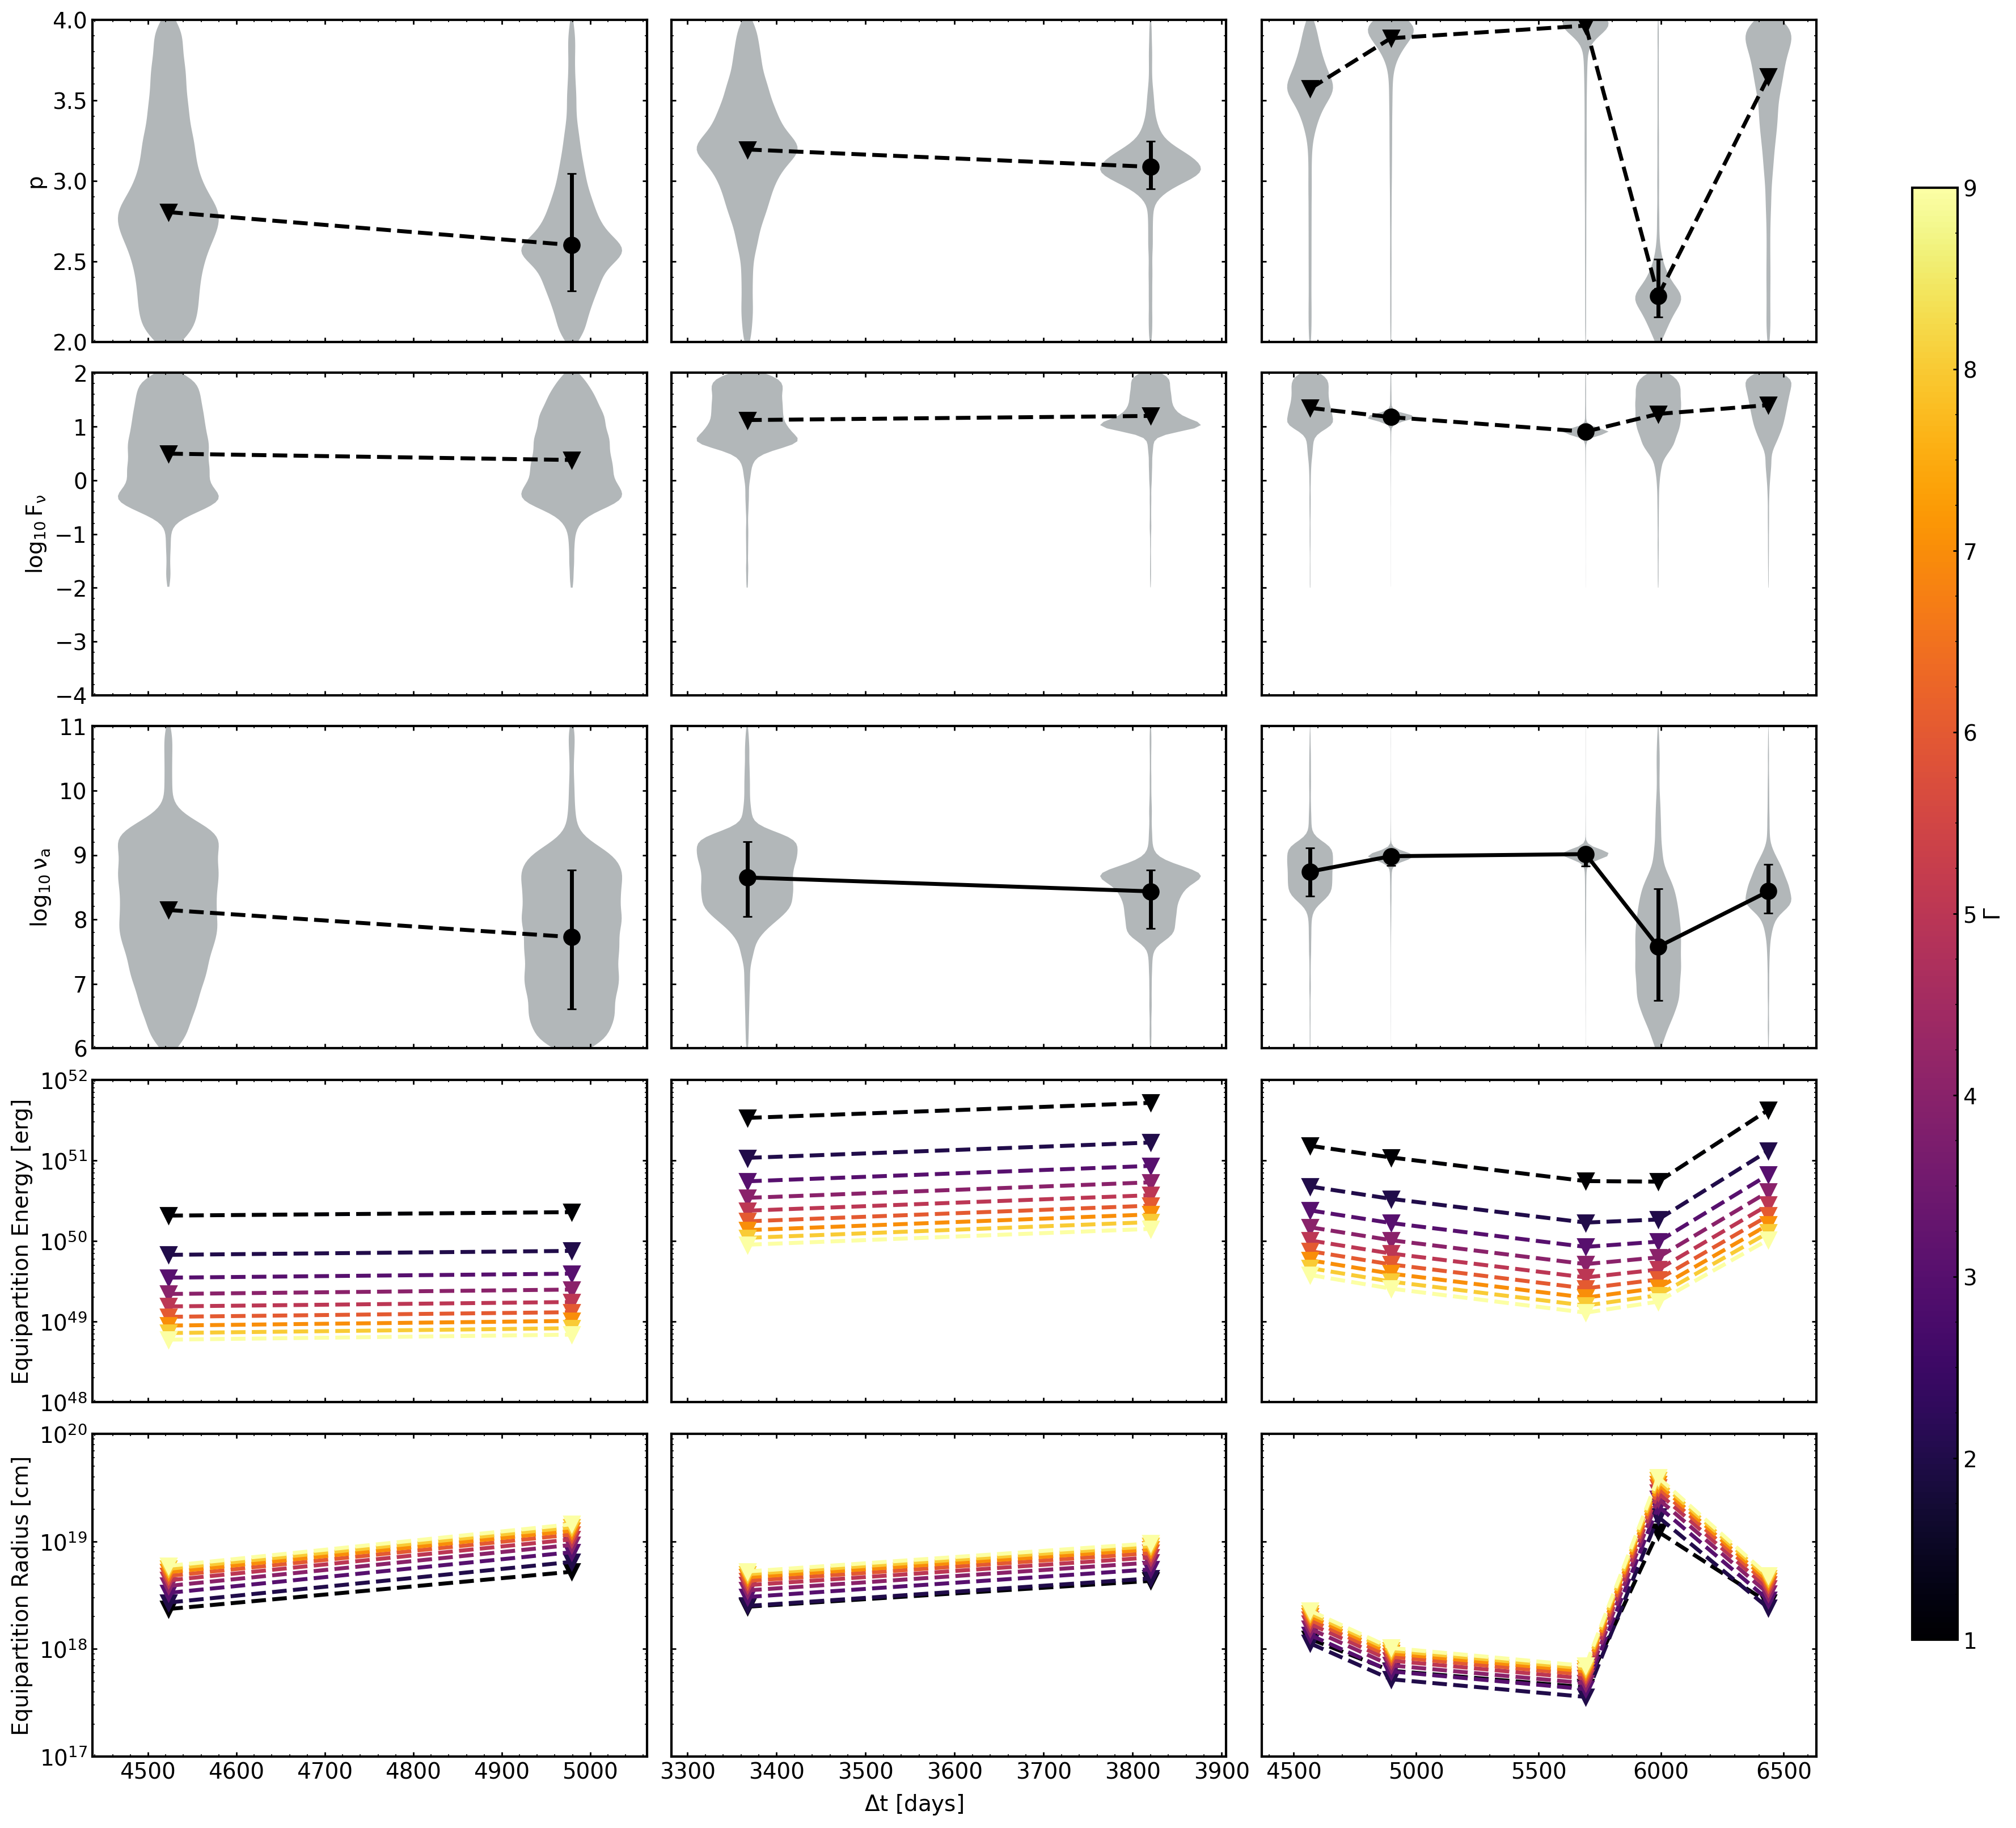

In [30]:
fig, axs = plt.subplots(5,3, sharex="col", sharey="row", figsize=(16,16), layout="constrained")


keys = {
    "p" : "p",
    "log_F_nu": r"$\log_{10} F_{\nu}$",
    "log_nu_a": r"$\log_{10} \nu_a$",
    "Eeq" : "Equipartition Energy [erg]",
    "Req" : "Equipartition Radius [cm]",
    # "Gamma" : r"$\Gamma$"
}

ranges = {
    "Eeq" : (1e48, 1e52),
    "Req" : (1e17, 1e20),
    # "p": (2,4),
    # "log_F_nu": (0,5),
    # "log_nu_a": (6,10)
    # "Gamma" : (1e1, 1e3)
}

colorbar_keys = {"Eeq", "Req"}

gammas = result_df.Gamma.unique()
n_lines = len(list(gammas))
cmap = mpl.colormaps['inferno']
colors = cmap(np.linspace(0,1,n_lines))

xvar = "dt"

priors = syncfit.models.B5().prior
ranges = priors | ranges # this will default to the priors but replace them with anything in ranges

label_fs = 14
ms = 10

for jj, (c, (gamma, df)) in enumerate(zip(colors, result_df.groupby("Gamma"))):
    for ii, (ax1d, (key, label)) in enumerate(zip(axs, keys.items())):
        ax1d[0].set_ylabel(label, fontsize=label_fs)
        for ax, (name, grp) in zip(ax1d, df.groupby("name")):
            if key in colorbar_keys:
                cplot = c
            elif jj > 0:
                continue # we can skip these keys the 2nd-nth time
            else:
                cplot = 'k'
            
            not_uplim = grp[~grp[key+"_uplim"]]
            ax.errorbar(
                not_uplim[xvar], 
                not_uplim[key], 
                yerr=(not_uplim[key+"_lo"], not_uplim[key+"_up"]), 
                marker='o', 
                linestyle='none', 
                color=cplot,
                capsize=3,
                markersize=ms
            )

            uplims = grp[grp[key+"_uplim"]]
            ax.plot(
                uplims[xvar],
                uplims[key],
                marker='v',
                linestyle='none',
                color=cplot,
                markersize=ms
            )
            
            if key not in colorbar_keys:
                # instead do a violin plot from the chains
                ax.violinplot(
                    grp[key+"_chain"].to_numpy(),
                    grp[xvar].to_numpy(),
                    showmeans=False, 
                    showmedians=False,
                    showextrema=False,
                    widths=np.abs(np.max(grp[xvar])-np.min(grp[xvar])) / (2*len(grp))
                )
                
            grp = grp.reset_index()
            for ii,row in grp.iterrows():
                
                if ii == 0:
                    # just check if the next one is an upperlimit
                    hasuplim = row[key+"_uplim"] or grp.iloc[ii+1][key+"_uplim"]
                elif ii == len(grp)-1:
                    hasuplim = row[key+"_uplim"] or grp.iloc[ii-1][key+"_uplim"]
                else:
                    hasuplim = row[key+"_uplim"] or grp.iloc[ii-1][key+"_uplim"] or grp.iloc[ii+1][key+"_uplim"]
                
                linestyle='-'
                if hasuplim:
                    linestyle='--'
                
                ax.plot(
                    grp.iloc[ii-1:ii+1][xvar],
                    grp.iloc[ii-1:ii+1][key],
                    marker='none',
                    linestyle=linestyle,
                    color=cplot
                )
                
            if not ii:
                ax.set_title(f"{name}", fontsize=label_fs)
    
            ax.set_ylim(*ranges[key])
            # ax.set_xscale("log")

axs[-1][0].set_yscale("log")
axs[-2][0].set_yscale("log")

cax = plt.axes((1.05, 0.1, 0.025, 0.8))
cbar = fig.colorbar(
    mpl.cm.ScalarMappable(cmap=cmap, norm=None), 
    cax=cax,
    ticks=np.linspace(0, 1, len(gammas)),
)
cbar.ax.set_ylabel(r"$\Gamma$", fontsize=label_fs)
cbar.ax.set_yticklabels(list(gammas), fontsize=label_fs)

fig.supxlabel(r"$\Delta$t [days]", fontsize=label_fs)

fig.savefig("equipartition-results-bootstrap.png", bbox_inches="tight")